# Actor-critic and PPO

### What the clip actually protects you from, which is not the thing everyone says

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a critic buys once it stops being only a baseline and starts supplying the target, how GAE turns bias against variance with one number, how PPO's clipped objective is written, and a measurement showing that the clip cannot stop the failure that motivated it and what it does stop instead |
| **You should already know** | [11-07 Policy gradients](../07-policy-gradients/): the score-function estimator, reward-to-go, and why variance is the whole problem |
| **Environment** | Cart-pole, the same class as [11-06](../06-deep-q-networks/) and [11-07](../07-policy-gradients/), written from scratch. No `gymnasium` |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [Part 12, the scoreboard](../../12-putting-it-together/) |

---

## 1. What is actually new here

[11-07](../07-policy-gradients/) finished with a table in which the winning
estimator was reward-to-go minus a learned baseline. That baseline was a small
network fitted to the returns, which means the previous chapter already had a
critic in it, and its own summary said so. So this chapter cannot honestly be
introduced as "now we add a value function". It was already there.

Two things are genuinely new, and they are the two halves of PPO.

**The critic supplies the target as well as the baseline.** In 11-07 the weight on
each log-probability was the observed return minus a prediction. The return part
came from the environment, summed to the end of the episode, and it carried every
scrap of noise in every reward and every action after step $t$. Once the critic is
any good, you can replace part of that sum with the critic's own estimate. That is
bootstrapping, it is the same trick as the $\max$ in Q-learning, and it trades an
unbiased and noisy weight for a biased and quiet one. GAE puts a dial on the
trade.

**The update stops being one step per batch.** REINFORCE collects a batch, takes
one gradient step, and throws the data away, because after the step the data came
from a policy that no longer exists. If you could correct for that mismatch you
could keep going on the same batch, and the correction is the probability ratio.
That is where PPO's sample efficiency comes from, and it is also where PPO's
danger comes from, which is what the clip is for.

### The claim I want to test

11-07 ended on a sweep that pushed a trained policy along its own gradient by
increasing distances and watched it go from working to destroyed. The usual
lesson drawn from that figure is: this is why PPO clips.

I want to check that sentence, because I do not think it survives contact with
the objective. Section 5 reruns that exact sweep with the clipped objective in
place and measures what the clip does to the resulting KL divergence. Lead with
the answer if you like: it does nothing at all, exactly and provably, and the clip
is protecting against a different failure.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
SEEDS = (0, 1)

GAMMA = 0.99
LAM = 0.95                    # the GAE dial, measured in section 2
CLIP = 0.2                    # PPO's clip width, the usual default
STEP_BUDGET = 40_000          # environment steps per run, as in 11-07
EPISODES_PER_BATCH = 5
MAX_STEPS = 500

In [2]:
class CartPole:
    """The cart-pole from 11-06 and 11-07, copied unchanged so the numbers compare.

    `step` returns (state, reward, done). `done` means the pole fell or the cart
    ran off the track, never "we hit the time limit", because the caller owns the
    time limit and the two have to be told apart when a critic bootstraps.
    """

    gravity = 9.8
    mass_cart = 1.0
    mass_pole = 0.1
    length = 0.5              # half the pole; the equations use half-lengths
    force_mag = 10.0
    tau = 0.02                # seconds per tick
    x_limit = 2.4
    angle_limit = 12.0 * np.pi / 180.0

    n_features = 4
    n_actions = 2

    def __init__(self, rng=None):
        self.rng = np.random.default_rng(SEED) if rng is None else rng
        self.state = np.zeros(4)

    def reset(self):
        self.state = self.rng.uniform(-0.05, 0.05, size=4)
        return self.state.astype(np.float32)

    def step(self, action):
        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        cos_t, sin_t = np.cos(theta), np.sin(theta)

        total_mass = self.mass_cart + self.mass_pole
        pole_ml = self.mass_pole * self.length

        temp = (force + pole_ml * theta_dot ** 2 * sin_t) / total_mass
        theta_acc = ((self.gravity * sin_t - cos_t * temp)
                     / (self.length * (4.0 / 3.0 - self.mass_pole * cos_t ** 2 / total_mass)))
        x_acc = temp - pole_ml * theta_acc * cos_t / total_mass

        x += self.tau * x_dot
        x_dot += self.tau * x_acc
        theta += self.tau * theta_dot
        theta_dot += self.tau * theta_acc
        self.state = np.array([x, x_dot, theta, theta_dot])

        done = bool(abs(x) > self.x_limit or abs(theta) > self.angle_limit)
        return self.state.astype(np.float32), 1.0, done


env = CartPole(np.random.default_rng(SEED))
s0 = env.reset()
s1, r1, d1 = env.step(1)
print(f"{env.n_features} continuous features, {env.n_actions} actions")
print(f"start state    : {np.round(s0, 4)}")
print(f"after one push : {np.round(s1, 4)}  reward {r1}  done {d1}")
print(f"failure at {np.degrees(env.angle_limit):.0f} degrees or {env.x_limit} metres, "
      f"episodes cut off at {MAX_STEPS} ticks")

4 continuous features, 2 actions
start state    : [ 0.0137 -0.023  -0.0459 -0.0483]
after one push : [ 0.0132  0.1727 -0.0469 -0.3552]  reward 1.0  done False
failure at 12 degrees or 2.4 metres, episodes cut off at 500 ticks


## 2. The maths

### The advantage

The quantity that belongs on a log-probability is the **advantage**:

$$A^\pi(s, a) = Q^\pi(s, a) - V^\pi(s)$$

How much better this action was than the average action in this state. Positive
advantage, make it more likely. Negative, less. Subtracting $V^\pi$ changes
nothing in expectation, because it does not depend on the action, which is the
baseline argument from 11-07.

Nobody has $A^\pi$. Every method in this chapter is a different estimate of it,
and they differ only in how much of the estimate comes from observed rewards and
how much from the critic.

### From Monte Carlo to one step, and the ladder in between

Write $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$, the one-step temporal
difference error. Then

$$\hat A_t^{(1)} = \delta_t, \qquad
\hat A_t^{(2)} = \delta_t + \gamma \delta_{t+1}, \qquad
\hat A_t^{(n)} = \sum_{k=0}^{n-1} \gamma^k \delta_{t+k}$$

At $n = 1$ the estimate leans entirely on the critic and inherits every error the
critic has, but it contains exactly one random reward and one random transition,
so it is quiet. At $n = \infty$ the sum telescopes into the Monte Carlo return
minus $V(s_t)$, which is 11-07's estimator: unbiased, and carrying the noise of
every step to the end of the episode.

### GAE

**Generalised advantage estimation** takes an exponentially weighted average over
the whole ladder rather than picking one rung:

$$\hat A_t^{\text{GAE}(\gamma, \lambda)}
= \sum_{k=0}^{\infty} (\gamma\lambda)^k \delta_{t+k}$$

which is computed backwards in one pass, exactly like a discounted return:

$$\hat A_t = \delta_t + \gamma\lambda \hat A_{t+1}$$

$\lambda = 0$ gives the one-step estimate. $\lambda = 1$ gives Monte Carlo minus
the baseline, which is 11-07's winning configuration. Everything interesting is
in between and the usual default is near the top of the range.

One detail that is easy to get wrong and changes the numbers. An episode that ends
because the pole fell has $V(s_{T}) = 0$, since nothing follows a terminal state.
An episode that ends because the caller cut it off at 500 ticks has not ended at
all, and using zero there tells the critic that surviving perfectly for 500 steps
is followed by nothing. The `terminated` flag on each episode below is what keeps
those two apart.

### PPO

Let $r_t(\theta) = \pi_\theta(a_t \mid s_t) / \pi_{\theta_{\text{old}}}(a_t \mid s_t)$.
Before any update $r_t = 1$ exactly. The clipped objective is

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\Big[\min\big(r_t \hat A_t,\;
\text{clip}(r_t, 1-\epsilon, 1+\epsilon)\, \hat A_t\big)\Big]$$

Read it one sample at a time. If $\hat A_t > 0$ the objective rises with $r_t$
until $r_t$ reaches $1 + \epsilon$, and then stops. If $\hat A_t < 0$ it rises as
$r_t$ falls until $1 - \epsilon$, and then stops. Past the edge of the window the
gradient from that sample is zero, so a single confident advantage estimate cannot
keep pushing.

Now notice what that means at $\theta = \theta_{\text{old}}$, which is where every
update starts. There $r_t = 1$ for every sample, no sample is outside the window,
and $\text{clip}$ is the identity with derivative one. The clipped objective and
the plain surrogate have **the same gradient at the starting point**. Section 5
measures that, because it decides what the clip can and cannot save you from.

## 3. From scratch

In [3]:
def make_policy(hidden=32):
    """Four numbers in, one logit per action out. Same shape as 11-07's."""
    return nn.Sequential(
        nn.Linear(CartPole.n_features, hidden), nn.Tanh(),
        nn.Linear(hidden, CartPole.n_actions),
    )


def make_value(hidden=32):
    """The critic: four numbers in, one estimate of the return from here out."""
    return nn.Sequential(
        nn.Linear(CartPole.n_features, hidden), nn.Tanh(),
        nn.Linear(hidden, 1),
    )


def sample_action(probs, rng):
    """Draw from a categorical distribution given as a probability vector."""
    return int(min(np.searchsorted(np.cumsum(probs), rng.random()), probs.size - 1))


def collect(policy, env, rng, n_episodes, max_steps=MAX_STEPS):
    """Run whole episodes. `terminated` tells a real ending from a time limit."""
    episodes = []
    for _ in range(n_episodes):
        state = env.reset()
        states, actions, rewards = [], [], []
        terminated = False
        for _ in range(max_steps):
            with torch.no_grad():
                probs = torch.softmax(policy(torch.from_numpy(state).unsqueeze(0)),
                                      dim=1).numpy()[0]
            action = sample_action(probs, rng)
            next_state, reward, done = env.step(action)
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            state = next_state
            if done:
                terminated = True
                break
        episodes.append({"states": np.array(states, dtype=np.float32),
                         "actions": np.array(actions, dtype=np.int64),
                         "rewards": np.array(rewards, dtype=np.float32),
                         "last_state": np.asarray(state, dtype=np.float32),
                         "terminated": terminated})
    return episodes


def discounted_returns(rewards, gamma):
    """Reward-to-go at every step, computed backwards in one pass."""
    out = np.zeros_like(rewards)
    running = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        running = rewards[t] + gamma * running
        out[t] = running
    return out


def flat(episodes):
    states = torch.from_numpy(np.concatenate([e["states"] for e in episodes]))
    actions = torch.from_numpy(np.concatenate([e["actions"] for e in episodes]))
    return states, actions


def log_probs(policy, states, actions):
    return torch.log_softmax(policy(states), dim=1).gather(1, actions.unsqueeze(1)).squeeze(1)


def gae(episode, value_net, gamma, lam):
    """GAE for one episode, plus the lambda-return the critic is fitted to."""
    states = torch.from_numpy(episode["states"])
    with torch.no_grad():
        v = value_net(states).squeeze(1).numpy()
        # Zero only if the episode really ended. A cut-off episode keeps its tail.
        v_last = 0.0 if episode["terminated"] else float(
            value_net(torch.from_numpy(episode["last_state"]).unsqueeze(0)).squeeze())

    rewards = episode["rewards"]
    advantage = np.zeros(len(rewards), dtype=np.float32)
    running, next_v = 0.0, v_last
    for t in range(len(rewards) - 1, -1, -1):
        delta = rewards[t] + gamma * next_v - v[t]
        running = delta + gamma * lam * running
        advantage[t] = running
        next_v = v[t]
    return advantage, advantage + v


def make_weights(episodes, value_net, gamma, lam):
    """The weight on each log-probability, and the target for the critic."""
    if value_net is None:
        w = np.concatenate([discounted_returns(e["rewards"], gamma) for e in episodes])
        return w.astype(np.float32), w.astype(np.float32)
    pairs = [gae(e, value_net, gamma, lam) for e in episodes]
    return (np.concatenate([a for a, _ in pairs]).astype(np.float32),
            np.concatenate([t for _, t in pairs]).astype(np.float32))

One training loop covers everything in this chapter. `lam` walks from 11-07's
estimator down to the one-step critic, `epochs` decides how many gradient steps
come out of one batch, and `clip` switches PPO's objective on.

The objective is a mean over samples rather than 11-07's sum over an episode
count. Adam divides each parameter's step by a running root-mean-square of its own
gradients, so a constant rescaling of the objective mostly cancels, and every
comparison in this notebook is against another run in this notebook.

In [4]:
def train(lam=LAM, critic=True, epochs=1, clip=None, lr=1e-2, seed=SEED,
          step_budget=STEP_BUDGET, episodes_per_batch=EPISODES_PER_BATCH,
          gamma=GAMMA, value_lr=2e-2, value_steps=5, max_steps=MAX_STEPS):
    """REINFORCE, actor-critic and PPO in one loop.

    critic=False   the weight is plain reward-to-go and no value network exists
    lam            the GAE dial. 1.0 is 11-07's Monte Carlo return minus a baseline
    epochs         gradient steps per batch. More than one needs the ratio to be honest
    clip           None for the plain surrogate, a width for PPO's clipped one
    """
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    env = CartPole(rng)

    policy = make_policy()
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    value_net = make_value() if critic else None
    value_opt = torch.optim.Adam(value_net.parameters(), lr=value_lr) if critic else None

    steps, history = 0, []

    while steps < step_budget:
        episodes = collect(policy, env, rng, episodes_per_batch, max_steps)
        steps += sum(len(e["rewards"]) for e in episodes)

        w, targets = make_weights(episodes, value_net, gamma, lam)
        states, actions = flat(episodes)
        w_t = torch.from_numpy(w)

        with torch.no_grad():
            old_logp = log_probs(policy, states, actions)
            old_dist = torch.log_softmax(policy(states), dim=1)

        clipped_fraction = 0.0
        for _ in range(epochs):
            logp = log_probs(policy, states, actions)
            if clip is None:
                # Re-evaluating the plain surrogate at the new parameters makes no
                # attempt to correct for the policy having moved. That is exactly
                # what the ratio below is for.
                objective = (logp * w_t).mean()
            else:
                ratio = torch.exp(logp - old_logp)
                objective = torch.minimum(ratio * w_t,
                                          torch.clamp(ratio, 1 - clip, 1 + clip) * w_t).mean()
                clipped_fraction += float(((ratio - 1.0).abs() > clip)
                                          .to(torch.float32).mean()) / epochs
            opt.zero_grad(set_to_none=True)
            (-objective).backward()
            opt.step()

        with torch.no_grad():
            new_dist = torch.log_softmax(policy(states), dim=1)
            kl = float((old_dist.exp() * (old_dist - new_dist)).sum(1).mean())

        if critic:
            # Fit the critic after using it, so the weights above came from the
            # value function as it stood when the data was collected.
            target_tensor = torch.from_numpy(targets)
            for _ in range(value_steps):
                loss = nn.functional.mse_loss(value_net(states).squeeze(1), target_tensor)
                value_opt.zero_grad(set_to_none=True)
                loss.backward()
                value_opt.step()

        history.append((steps, float(np.mean([len(e["rewards"]) for e in episodes])),
                        kl, clipped_fraction))

    return policy, value_net, np.array(history)


def evaluate_policy(policy, seed, n_episodes=10, max_steps=MAX_STEPS, greedy=False):
    """Mean episode length under the learned policy, sampled or taken greedily."""
    rng = np.random.default_rng(seed)
    env = CartPole(rng)
    lengths = []
    for _ in range(n_episodes):
        state = env.reset()
        length = 0
        for _ in range(max_steps):
            with torch.no_grad():
                probs = torch.softmax(policy(torch.from_numpy(state).unsqueeze(0)),
                                      dim=1).numpy()[0]
            action = int(probs.argmax()) if greedy else sample_action(probs, rng)
            state, _, done = env.step(action)
            length += 1
            if done:
                break
        lengths.append(length)
    return float(np.mean(lengths))

### What lambda costs and what it buys, measured

Before training anything, the same measurement 11-07 used on its estimators. Train
a short warm-up run to get a partly trained policy and critic, collect one pool of
episodes, and reuse that pool for every value of $\lambda$ so the comparison is
paired.

Two numbers per $\lambda$. The **noise to signal ratio** is the square root of the
total variance of the per-batch gradient divided by the length of the mean
gradient, which is 11-07's definition. The **direction agreement** is the cosine
between this $\lambda$'s mean gradient and the mean gradient at $\lambda = 1$,
which is the unbiased one. Lower noise is the prize and falling agreement is the
price.

In [5]:
started = time.perf_counter()
warm_policy, warm_value, warm_history = train(step_budget=9_000, seed=SEED)
print(f"warm-up run: {len(warm_history)} updates over {int(warm_history[-1, 0]):,} "
      f"environment steps [{time.perf_counter() - started:.1f}s]")
print(f"mean episode length, first batch: {warm_history[0, 1]:.1f}")
print(f"mean episode length, last batch : {warm_history[-1, 1]:.1f}")

POOL_BATCHES = 40
POOL_CAP = 300               # cap episode length here so the pool cannot blow up

pool_rng = np.random.default_rng(1234)
pool = collect(warm_policy, CartPole(pool_rng), pool_rng,
               POOL_BATCHES * EPISODES_PER_BATCH, POOL_CAP)
batches = [pool[i * EPISODES_PER_BATCH:(i + 1) * EPISODES_PER_BATCH]
           for i in range(POOL_BATCHES)]
print(f"\npool: {len(pool)} episodes, {sum(len(e['rewards']) for e in pool):,} "
      f"environment steps, mean length {np.mean([len(e['rewards']) for e in pool]):.1f}")
print(f"episodes cut off by the {POOL_CAP}-step cap rather than falling: "
      f"{sum(not e['terminated'] for e in pool)}")

warm-up run: 33 updates over 9,140 environment steps [5.7s]
mean episode length, first batch: 15.6
mean episode length, last batch : 148.2



pool: 200 episodes, 32,733 environment steps, mean length 163.7
episodes cut off by the 300-step cap rather than falling: 13


In [6]:
def gradient_vector(policy, episodes, value_net, gamma, lam):
    """One flattened policy-gradient estimate from one batch of episodes."""
    w, _ = make_weights(episodes, value_net, gamma, lam)
    states, actions = flat(episodes)
    objective = (log_probs(policy, states, actions) * torch.from_numpy(w)).mean()
    grads = torch.autograd.grad(objective, list(policy.parameters()))
    return torch.cat([g.reshape(-1) for g in grads]).numpy()


LAMBDAS = [0.0, 0.5, 0.9, 0.95, 0.99, 1.0]

started = time.perf_counter()
means, ratios = {}, []
for lam in LAMBDAS:
    G = np.stack([gradient_vector(warm_policy, b, warm_value, GAMMA, lam) for b in batches])
    mean_g = G.mean(axis=0)
    means[lam] = mean_g
    ratios.append({"lambda": lam,
                   "gradient variance": float(G.var(axis=0, ddof=1).sum()),
                   "signal, |mean gradient|": float(np.linalg.norm(mean_g)),
                   "noise / signal": float(np.sqrt(G.var(axis=0, ddof=1).sum())
                                           / np.linalg.norm(mean_g))})

lam_table = pd.DataFrame(ratios)
lam_table["agreement with λ = 1"] = [
    float(means[lam] @ means[1.0] / (np.linalg.norm(means[lam]) * np.linalg.norm(means[1.0])))
    for lam in LAMBDAS]

print(f"{POOL_BATCHES} batches of {EPISODES_PER_BATCH} episodes, one pool, "
      f"every lambda measured on it [{time.perf_counter() - started:.1f}s]\n")
print(lam_table.to_string(index=False, float_format=lambda v: f"{v:10.4g}"))

40 batches of 5 episodes, one pool, every lambda measured on it [13.5s]

    lambda  gradient variance  signal, |mean gradient|  noise / signal  agreement with λ = 1
         0             0.1055                   0.7105          0.4571                0.9451
       0.5            0.07322                   0.5469          0.4948                0.9566
       0.9             0.1856                   0.5514          0.7813                0.9681
      0.95             0.3681                   0.7461          0.8131                0.9698
      0.99              1.265                    1.214          0.9265                0.9932
         1              2.409                     1.48           1.049                     1


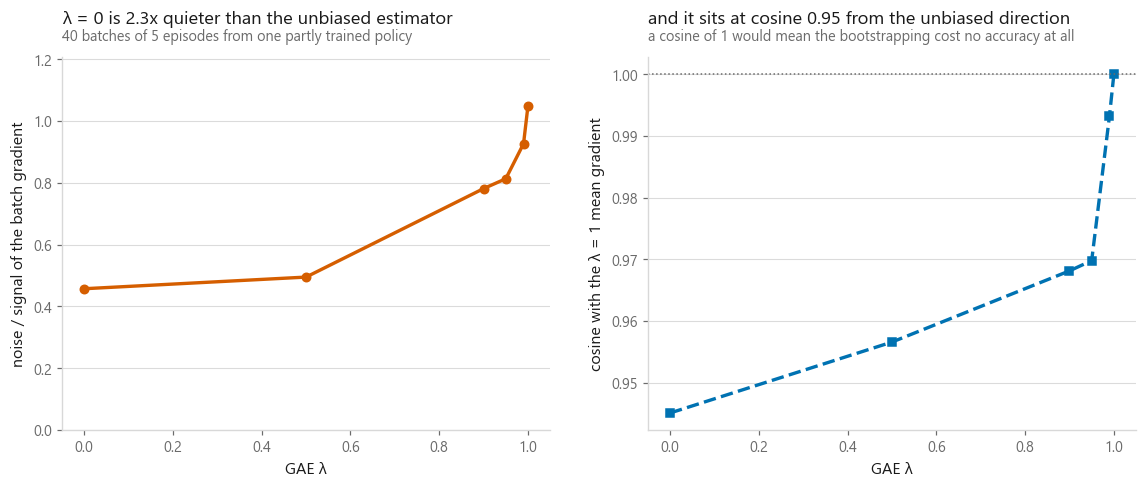

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

mc = lam_table.set_index("lambda").loc[1.0]
td = lam_table.set_index("lambda").loc[0.0]
factor = float(mc["noise / signal"]) / float(td["noise / signal"])
verdict = "quieter" if factor > 1 else "noisier"

ax = axes[0]
ax.plot(LAMBDAS, lam_table["noise / signal"], color=style.HIGHLIGHT, lw=2.2,
        marker=style.MARKERS[0], label="noise / signal")
ax.set_xlabel("GAE λ")
ax.set_ylabel("noise / signal of the batch gradient")
ax.set_ylim(0, float(lam_table["noise / signal"].max()) * 1.15)
style.title(ax,
            f"λ = 0 is {max(factor, 1 / factor):.1f}x {verdict} than the unbiased estimator",
            f"{POOL_BATCHES} batches of {EPISODES_PER_BATCH} episodes from one partly trained policy")

ax = axes[1]
ax.plot(LAMBDAS, lam_table["agreement with λ = 1"], color=style.PALETTE[0], lw=2.2,
        ls="--", marker=style.MARKERS[1])
ax.axhline(1.0, color=style.MUTED, lw=1.0, ls=":")
ax.set_xlabel("GAE λ")
ax.set_ylabel("cosine with the λ = 1 mean gradient")
style.title(ax,
            f"and it sits at cosine {float(td['agreement with λ = 1']):.2f} "
            f"from the unbiased direction",
            "a cosine of 1 would mean the bootstrapping cost no accuracy at all")

style.save(fig, FIG / "fig-01-lambda-tradeoff.png")

### Four estimators, same budget, same seeds

Now the training runs. Same network, same learning rate, same batch size, same
discount, same budget of environment steps, two seeds each. The only thing that
changes is what goes into the weight.

The second row is 11-07's winning configuration, rebuilt here so that every number
in this chapter comes from this notebook. It differs from 11-07 in one respect:
an episode cut off at 500 ticks now has its tail estimated by the critic instead
of being treated as if the world ended.

In [8]:
CONFIGS = {
    "reward-to-go, no critic": dict(critic=False),
    "critic as baseline, λ = 1": dict(critic=True, lam=1.0),
    "GAE, λ = 0.95": dict(critic=True, lam=0.95),
    "one-step TD, λ = 0": dict(critic=True, lam=0.0),
}

started = time.perf_counter()
runs, models, critics = {}, {}, {}
for name, cfg in CONFIGS.items():
    for seed in SEEDS:
        policy, value_net, history = train(seed=seed, **cfg)
        runs[name, seed], models[name, seed], critics[name, seed] = history, policy, value_net
    final = np.mean([runs[name, s][-6:, 1].mean() for s in SEEDS])
    print(f"{name:<28} last batches, mean over seeds: {final:6.1f} steps"
          f"   [{time.perf_counter() - started:5.1f}s elapsed]")

reward-to-go, no critic      last batches, mean over seeds:  347.1 steps   [ 16.8s elapsed]


critic as baseline, λ = 1    last batches, mean over seeds:  432.5 steps   [ 39.4s elapsed]


GAE, λ = 0.95                last batches, mean over seeds:  422.0 steps   [ 76.7s elapsed]


one-step TD, λ = 0           last batches, mean over seeds:  348.9 steps   [131.7s elapsed]


In [9]:
GRID = np.linspace(0, STEP_BUDGET, 90)


def band(histories, window=5, column=1):
    """Smooth each seed, put them on one step axis, return mean and the envelope."""
    curves = []
    for h in histories:
        smooth = pd.Series(h[:, column]).rolling(window, min_periods=1).mean().to_numpy()
        curves.append(np.interp(GRID, h[:, 0], smooth))
    curves = np.stack(curves)
    return curves.mean(0), curves.min(0), curves.max(0)


summary = pd.DataFrame({
    "weight": list(CONFIGS),
    "last quarter": [np.mean([np.interp(GRID[-22:], runs[n, s][:, 0], runs[n, s][:, 1]).mean()
                              for s in SEEDS]) for n in CONFIGS],
    "best batch": [np.mean([runs[n, s][:, 1].max() for s in SEEDS]) for n in CONFIGS],
    "seed spread (last)": [abs(runs[n, SEEDS[0]][-6:, 1].mean()
                               - runs[n, SEEDS[1]][-6:, 1].mean()) for n in CONFIGS],
    "mean KL per update": [np.mean([runs[n, s][:, 2].mean() for s in SEEDS]) for n in CONFIGS],
    "updates used": [np.mean([len(runs[n, s]) for s in SEEDS]) for n in CONFIGS],
    "fresh episodes, sampled": [np.mean([evaluate_policy(models[n, s], 500 + s) for s in SEEDS])
                                for n in CONFIGS],
}).round(2)

print(f"{STEP_BUDGET:,} environment steps per run, {len(SEEDS)} seeds, "
      f"ten fresh episodes per seed in the last column")
print(summary.to_string(index=False))

best_config = summary.loc[summary["fresh episodes, sampled"].idxmax(), "weight"]
mc_row = summary.set_index("weight").loc["critic as baseline, λ = 1"]
gae_row = summary.set_index("weight").loc["GAE, λ = 0.95"]
print(f"\nbest on fresh episodes: {best_config}")
print(f"bootstrapping moved the final score by "
      f"{gae_row['fresh episodes, sampled'] - mc_row['fresh episodes, sampled']:+.1f} steps "
      f"against 11-07's estimator")

40,000 environment steps per run, 2 seeds, ten fresh episodes per seed in the last column
                   weight  last quarter  best batch  seed spread (last)  mean KL per update  updates used  fresh episodes, sampled
  reward-to-go, no critic        342.66       423.1              193.80                 0.0          69.5                   427.35
critic as baseline, λ = 1        445.72       481.7               33.33                 0.0          53.0                   454.95
            GAE, λ = 0.95        415.43       477.9               12.07                 0.0          55.5                   476.50
       one-step TD, λ = 0        343.92       435.4               92.30                 0.0          74.0                   323.50

best on fresh episodes: GAE, λ = 0.95
bootstrapping moved the final score by +21.6 steps against 11-07's estimator


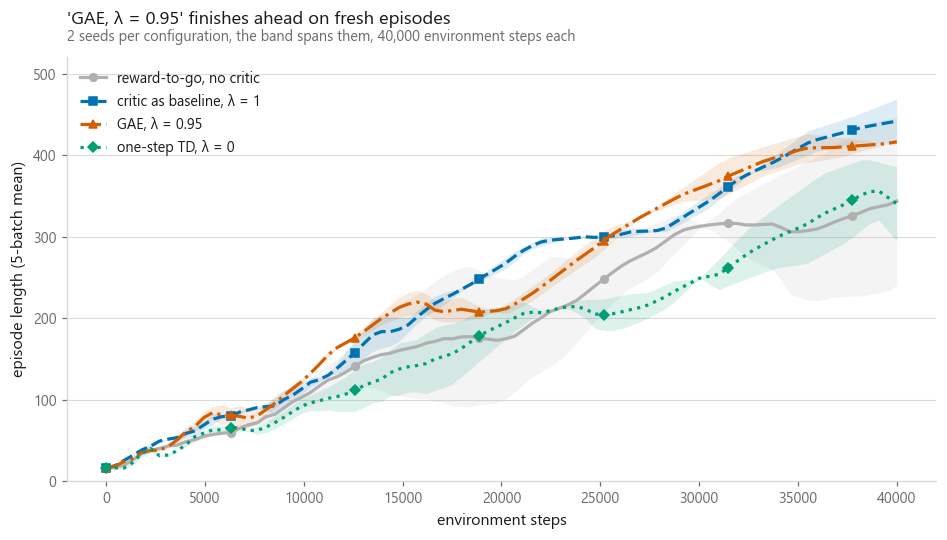

In [10]:
colours = [style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[2]]

fig, ax = plt.subplots(figsize=(10.2, 5.0))
for i, name in enumerate(CONFIGS):
    mean, low, high = band([runs[name, s] for s in SEEDS])
    ax.fill_between(GRID, low, high, color=colours[i], alpha=0.13, linewidth=0)
    ax.plot(GRID, mean, color=colours[i], lw=2.1, ls=style.DASHES[i], label=name,
            marker=style.MARKERS[i], markevery=14, markersize=5)
ax.set_xlabel("environment steps")
ax.set_ylabel("episode length (5-batch mean)")
ax.set_ylim(0, 520)
ax.legend(loc="upper left", fontsize=9.5)
style.title(ax,
            f"'{best_config}' finishes ahead on fresh episodes",
            f"{len(SEEDS)} seeds per configuration, the band spans them, "
            f"{STEP_BUDGET:,} environment steps each")
style.save(fig, FIG / "fig-02-estimators.png")

### The rest of the dial

Two more values of $\lambda$ so the curve has enough points to have a shape, and
the final score plotted against the noise measurement from section 2.

In [11]:
started = time.perf_counter()
sweep = {}
for lam in LAMBDAS:
    for seed in SEEDS:
        if lam == 1.0:
            sweep[lam, seed] = runs["critic as baseline, λ = 1", seed]
        elif lam == 0.95:
            sweep[lam, seed] = runs["GAE, λ = 0.95", seed]
        elif lam == 0.0:
            sweep[lam, seed] = runs["one-step TD, λ = 0", seed]
        else:
            sweep[lam, seed] = train(lam=lam, seed=seed)[2]
print(f"lambda sweep finished [{time.perf_counter() - started:.1f}s]")

lam_scores = np.array([np.mean([sweep[lam, s][-6:, 1].mean() for s in SEEDS])
                       for lam in LAMBDAS])
lam_table["final episode length"] = lam_scores
print()
print(lam_table[["lambda", "noise / signal", "agreement with λ = 1",
                 "final episode length"]].to_string(index=False,
                                                    float_format="{:.3f}".format))

lambda sweep finished [66.0s]

 lambda  noise / signal  agreement with λ = 1  final episode length
  0.000           0.457                 0.945               348.883
  0.500           0.495                 0.957               192.667
  0.900           0.781                 0.968               346.350
  0.950           0.813                 0.970               422.033
  0.990           0.926                 0.993               433.850
  1.000           1.049                 1.000               432.533


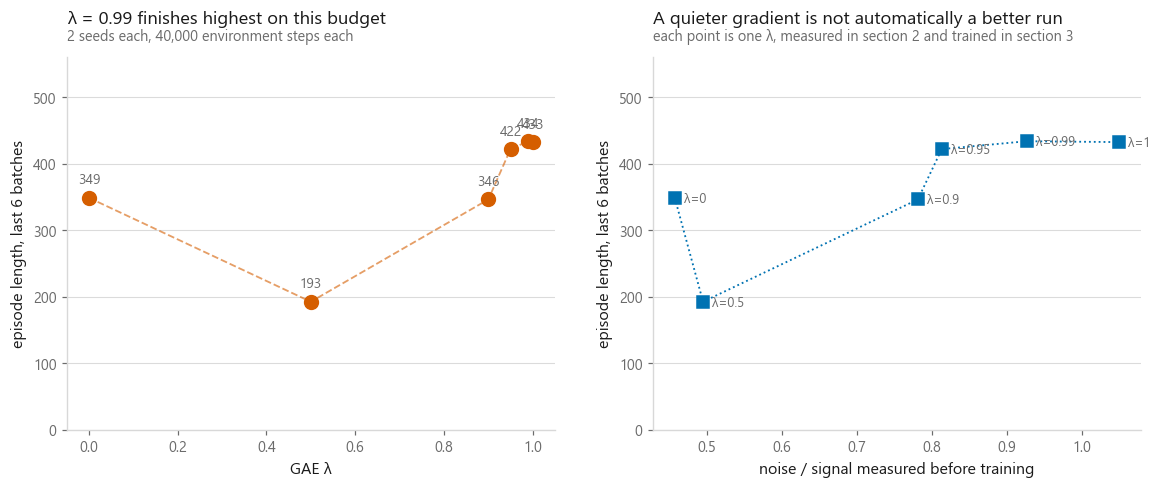

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.plot(LAMBDAS, lam_scores, color=style.HIGHLIGHT, lw=0, marker=style.MARKERS[0],
        markersize=9)
for lam, score in zip(LAMBDAS, lam_scores):
    ax.annotate(f"{score:.0f}", xy=(lam, score), xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=9, color=style.MUTED)
ax.plot(LAMBDAS, lam_scores, color=style.HIGHLIGHT, lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("GAE λ")
ax.set_ylabel("episode length, last 6 batches")
ax.set_ylim(0, 560)
best_lam = LAMBDAS[int(np.argmax(lam_scores))]
style.title(ax, f"λ = {best_lam:g} finishes highest on this budget",
            f"{len(SEEDS)} seeds each, {STEP_BUDGET:,} environment steps each")

ax = axes[1]
ax.plot(lam_table["noise / signal"], lam_scores, color=style.PALETTE[0], lw=1.2,
        ls=":", marker=style.MARKERS[1], markersize=8)
for lam, ns, score in zip(LAMBDAS, lam_table["noise / signal"], lam_scores):
    ax.annotate(f"λ={lam:g}", xy=(ns, score), xytext=(6, -3), textcoords="offset points",
                fontsize=8.5, color=style.MUTED)
ax.set_xlabel("noise / signal measured before training")
ax.set_ylabel("episode length, last 6 batches")
ax.set_ylim(0, 560)
style.title(ax, "A quieter gradient is not automatically a better run",
            "each point is one λ, measured in section 2 and trained in section 3")

style.save(fig, FIG / "fig-03-lambda-sweep.png")

## 4. PPO

Everything so far takes one gradient step per batch and then throws the batch
away. PPO keeps the batch and takes several, which is where its sample efficiency
comes from, and clips the ratio so that the extra steps cannot run away.

Three runs, same budget as everything above.

**One step, no clip** is section 3's GAE configuration, unchanged. **Ten steps,
no clip** is the naive way to reuse a batch: keep optimising the plain surrogate
at parameters that no longer generated the data, with no correction for the fact
that they no longer generated it. **Ten steps, clipped** is PPO.

The number to watch is the clip fraction, printed per run below. A clip fraction
near zero means the ratio never left the window, which means the clip was
inactive and PPO was doing nothing that plain reuse would not have done.

In [13]:
PPO_LR = 3e-3
PPO_EPOCHS = 10

METHODS = {
    "one step, no clip": dict(epochs=1, clip=None, lr=1e-2),
    "ten steps, no clip": dict(epochs=PPO_EPOCHS, clip=None, lr=PPO_LR),
    "ten steps, clipped (PPO)": dict(epochs=PPO_EPOCHS, clip=CLIP, lr=PPO_LR),
}

started = time.perf_counter()
ppo_runs, ppo_models = {}, {}
for name, cfg in METHODS.items():
    for seed in SEEDS:
        # The first row repeats section 3's GAE configuration exactly. Running it
        # again rather than reaching into `runs` keeps all three rows coming out of
        # one call site, and its numbers should match to the digit.
        policy, _, history = train(lam=LAM, critic=True, seed=seed, **cfg)
        ppo_runs[name, seed], ppo_models[name, seed] = history, policy
    print(f"{name:<26} last batches: "
          f"{np.mean([ppo_runs[name, s][-6:, 1].mean() for s in SEEDS]):6.1f} steps"
          f"   [{time.perf_counter() - started:5.1f}s elapsed]")

ppo_summary = pd.DataFrame({
    "method": list(METHODS),
    "last quarter": [np.mean([np.interp(GRID[-22:], ppo_runs[n, s][:, 0],
                                        ppo_runs[n, s][:, 1]).mean() for s in SEEDS])
                     for n in METHODS],
    "fresh episodes, sampled": [np.mean([evaluate_policy(ppo_models[n, s], 500 + s)
                                         for s in SEEDS]) for n in METHODS],
    "mean KL per batch": [np.mean([ppo_runs[n, s][:, 2].mean() for s in SEEDS])
                          for n in METHODS],
    "largest KL in the run": [np.mean([ppo_runs[n, s][:, 2].max() for s in SEEDS])
                              for n in METHODS],
    "clip fraction": [np.mean([ppo_runs[n, s][:, 3].mean() for s in SEEDS]) for n in METHODS],
    "gradient steps": [np.mean([len(ppo_runs[n, s]) * METHODS[n]["epochs"] for s in SEEDS])
                       for n in METHODS],
}).round(4)

print()
print(ppo_summary.to_string(index=False))

one step, no clip          last batches:  422.0 steps   [ 19.0s elapsed]


ten steps, no clip         last batches:  222.0 steps   [ 53.2s elapsed]


ten steps, clipped (PPO)   last batches:  463.4 steps   [ 72.0s elapsed]



                  method  last quarter  fresh episodes, sampled  mean KL per batch  largest KL in the run  clip fraction  gradient steps
       one step, no clip      415.4273                    476.5             0.0013                 0.0069          0.000            55.5
      ten steps, no clip      245.5774                    234.0             0.0160                 0.7498          0.000          2705.0
ten steps, clipped (PPO)      461.3402                    444.3             0.0080                 0.0346          0.031           395.0


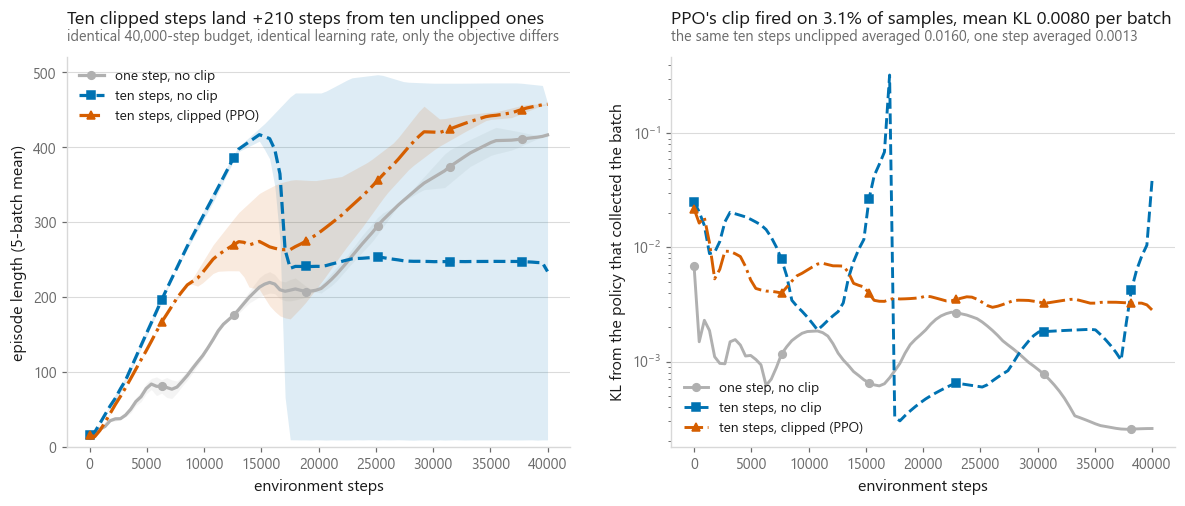

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
ppo_colours = [style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT]

ax = axes[0]
for i, name in enumerate(METHODS):
    mean, low, high = band([ppo_runs[name, s] for s in SEEDS])
    ax.fill_between(GRID, low, high, color=ppo_colours[i], alpha=0.13, linewidth=0)
    ax.plot(GRID, mean, color=ppo_colours[i], lw=2.1, ls=style.DASHES[i], label=name,
            marker=style.MARKERS[i], markevery=14, markersize=5)
ax.set_xlabel("environment steps")
ax.set_ylabel("episode length (5-batch mean)")
ax.set_ylim(0, 520)
ax.legend(loc="upper left", fontsize=9)
naive = ppo_summary.set_index("method").loc["ten steps, no clip"]
ppo = ppo_summary.set_index("method").loc["ten steps, clipped (PPO)"]
style.title(ax,
            f"Ten clipped steps land {ppo['fresh episodes, sampled'] - naive['fresh episodes, sampled']:+.0f} "
            f"steps from ten unclipped ones",
            f"identical {STEP_BUDGET:,}-step budget, identical learning rate, "
            f"only the objective differs")

ax = axes[1]
for i, name in enumerate(METHODS):
    mean, low, high = band([ppo_runs[name, s] for s in SEEDS], window=3, column=2)
    ax.plot(GRID, mean, color=ppo_colours[i], lw=1.9, ls=style.DASHES[i], label=name,
            marker=style.MARKERS[i], markevery=17, markersize=5)
ax.set_yscale("log")
ax.set_xlabel("environment steps")
ax.set_ylabel("KL from the policy that collected the batch")
ax.legend(loc="lower left", fontsize=9)
style.title(ax,
            f"PPO's clip fired on {ppo['clip fraction']:.1%} of samples, mean KL "
            f"{ppo['mean KL per batch']:.4f} per batch",
            f"the same ten steps unclipped averaged {naive['mean KL per batch']:.4f}, "
            f"one step averaged {ppo_summary.set_index('method').loc['one step, no clip', 'mean KL per batch']:.4f}")

style.save(fig, FIG / "fig-04-ppo.png")

## 5. What the clip can and cannot save you from

### The failure from 11-07, rerun with the clip in place

[11-07](../07-policy-gradients/) took a trained policy, pushed it along its own
estimated gradient by a range of distances, and recorded how far the distribution
moved in KL and what the policy scored afterwards. Small steps did nothing, one
step past a threshold destroyed it, and the chapter said that was why PPO exists.

Here is that sweep again, with one addition. I compute the gradient of the plain
surrogate and the gradient of the clipped objective at the same starting point,
and step along each of them.

In [15]:
probe_rng = np.random.default_rng(99)
probe_policy = ppo_models["one step, no clip", 0]
probe_critic = critics["GAE, λ = 0.95", 0]
probe = collect(probe_policy, CartPole(probe_rng), probe_rng, 10, 300)

probe_w, _ = make_weights(probe, probe_critic, GAMMA, LAM)
probe_states, probe_actions = flat(probe)
probe_w_t = torch.from_numpy(probe_w)

with torch.no_grad():
    probe_old_logp = log_probs(probe_policy, probe_states, probe_actions)
    probe_old_dist = torch.log_softmax(probe_policy(probe_states), dim=1)


def flat_grad(objective, policy):
    grads = torch.autograd.grad(objective, list(policy.parameters()))
    return torch.cat([g.reshape(-1) for g in grads]).numpy()


plain_objective = (log_probs(probe_policy, probe_states, probe_actions) * probe_w_t).mean()
plain_grad = flat_grad(plain_objective, probe_policy)

ratio0 = torch.exp(log_probs(probe_policy, probe_states, probe_actions) - probe_old_logp)
clipped_objective = torch.minimum(ratio0 * probe_w_t,
                                  torch.clamp(ratio0, 1 - CLIP, 1 + CLIP) * probe_w_t).mean()
clipped_grad = flat_grad(clipped_objective, probe_policy)

print(f"probe batch: {len(probe)} episodes, {probe_states.shape[0]:,} samples")
print(f"ratio at the starting point: min {float(ratio0.min()):.6f}, "
      f"max {float(ratio0.max()):.6f}")
print(f"fraction of samples outside the clip window: "
      f"{float(((ratio0 - 1).abs() > CLIP).to(torch.float32).mean()):.4f}")
print(f"\nlargest disagreement between the two gradients: "
      f"{np.abs(plain_grad - clipped_grad).max():.3e}")
print(f"cosine between them: "
      f"{plain_grad @ clipped_grad / (np.linalg.norm(plain_grad) * np.linalg.norm(clipped_grad)):.10f}")

probe batch: 10 episodes, 2,930 samples
ratio at the starting point: min 1.000000, max 1.000000
fraction of samples outside the clip window: 0.0000

largest disagreement between the two gradients: 0.000e+00
cosine between them: 1.0000000000


C:\Users\pilot\AppData\Local\Temp\ipykernel_18668\2343819160.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print(f"ratio at the starting point: min {float(ratio0.min()):.6f}, "


In [16]:
saved = [p.detach().clone() for p in probe_policy.parameters()]


def set_offset(size, direction):
    """theta <- theta_saved + size * unit direction."""
    offset = 0
    with torch.no_grad():
        for p, base in zip(probe_policy.parameters(), saved):
            n = p.numel()
            chunk = torch.from_numpy(direction[offset:offset + n].astype(np.float32))
            p.copy_(base + size * chunk.reshape(p.shape))
            offset += n


def kl_from_start():
    with torch.no_grad():
        new_dist = torch.log_softmax(probe_policy(probe_states), dim=1)
    return float((probe_old_dist.exp() * (probe_old_dist - new_dist)).sum(1).mean())


SIZES = (0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0)
directions = {"plain surrogate": plain_grad / np.linalg.norm(plain_grad),
              "clipped objective": clipped_grad / np.linalg.norm(clipped_grad)}

single = []
for size in SIZES:
    row = {"step in parameter space": size}
    for label, direction in directions.items():
        set_offset(size, direction)
        row[f"KL, {label}"] = kl_from_start()
        row[f"score, {label}"] = evaluate_policy(probe_policy, 4242, n_episodes=8, max_steps=400)
    single.append(row)
set_offset(0.0, plain_grad)          # put the policy back before anything else uses it

single = pd.DataFrame(single)
print("one step along the estimated gradient, from a trained policy")
print(single.to_string(index=False, float_format=lambda v: f"{v:10.4g}"))
print(f"\nlargest KL difference between the two columns: "
      f"{np.abs(single['KL, plain surrogate'] - single['KL, clipped objective']).max():.3e}")

one step along the estimated gradient, from a trained policy
 step in parameter space  KL, plain surrogate  score, plain surrogate  KL, clipped objective  score, clipped objective
                       0                    0                     400                      0                       400
                    0.03            0.0008053                     400              0.0008053                       400
                     0.1             0.008935                   393.5               0.008935                     393.5
                     0.3              0.07933                   266.2                0.07933                     266.2
                       1               0.7747                   29.12                 0.7747                     29.12
                       3                4.158                   12.88                  4.158                     12.88
                      10                 16.7                    9.75                   16.7              

The two columns hold the same numbers, to every digit printed, and the line under
the table gives the largest disagreement between them.

That is not a coincidence and it is not a bug in the sweep. At the starting point
every ratio is exactly 1, no sample is outside the window, and clipping is the
identity function with derivative one. The clipped objective and the plain
surrogate are locally the same function, so their gradients are the same vector,
so a step along either one lands in the same place and moves the distribution by
the same KL.

**The clip cannot stop a single oversized update.** If your learning rate is too
large, PPO's objective will wreck the policy exactly as fast as REINFORCE's will.
Every explanation that presents the clip as a limit on how far one update may move
the policy is describing TRPO, which really does solve a constrained problem, and
not PPO.

### What it does stop

The clip needs the ratio to have moved before it can do anything, and the ratio
only moves once you have taken a step. So it bites in the regime PPO was written
for: several gradient steps on one batch, where each step after the first is
evaluated at parameters that no longer generated the data.

Below, the same batch and the same starting policy, ten Adam steps at a range of
learning rates, with the clip on and off. Nothing here trains, so the only thing
that varies is the objective being optimised.

In [17]:
LRS = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2]
PROBE_EPOCHS = 10


def optimise_batch(lr, clip, epochs=PROBE_EPOCHS):
    """Restore the probe policy, then take `epochs` Adam steps on the one batch."""
    with torch.no_grad():
        for p, base in zip(probe_policy.parameters(), saved):
            p.copy_(base)
    opt = torch.optim.Adam(probe_policy.parameters(), lr=lr)

    fired = 0.0
    for _ in range(epochs):
        logp = log_probs(probe_policy, probe_states, probe_actions)
        if clip is None:
            objective = (logp * probe_w_t).mean()
        else:
            ratio = torch.exp(logp - probe_old_logp)
            objective = torch.minimum(ratio * probe_w_t,
                                      torch.clamp(ratio, 1 - clip, 1 + clip) * probe_w_t).mean()
            fired += float(((ratio - 1.0).abs() > clip).to(torch.float32).mean()) / epochs
        opt.zero_grad(set_to_none=True)
        (-objective).backward()
        opt.step()

    result = {"KL": kl_from_start(), "clip fraction": fired,
              "score": evaluate_policy(probe_policy, 4242, n_episodes=8, max_steps=400)}
    return result


started = time.perf_counter()
reuse = []
for lr in LRS:
    off = optimise_batch(lr, None)
    on = optimise_batch(lr, CLIP)
    reuse.append({"learning rate": lr,
                  "KL, no clip": off["KL"], "KL, clipped": on["KL"],
                  "score, no clip": off["score"], "score, clipped": on["score"],
                  "clip fraction": on["clip fraction"]})
with torch.no_grad():
    for p, base in zip(probe_policy.parameters(), saved):
        p.copy_(base)

reuse = pd.DataFrame(reuse)
print(f"{PROBE_EPOCHS} Adam steps on one fixed batch, policy restored between rows "
      f"[{time.perf_counter() - started:.1f}s]\n")
print(reuse.to_string(index=False, float_format=lambda v: f"{v:10.4g}"))
print(f"\nscore of the untouched policy: "
      f"{evaluate_policy(probe_policy, 4242, n_episodes=8, max_steps=400):.1f}")

10 Adam steps on one fixed batch, policy restored between rows [5.3s]

 learning rate  KL, no clip  KL, clipped  score, no clip  score, clipped  clip fraction
        0.0001    5.686e-05    5.696e-05             400             400              0
        0.0003    0.0005077    0.0005107             400             400              0
         0.001     0.005395      0.00501             400             400       0.007235
         0.003      0.03791      0.01054           372.5           397.2         0.1144
          0.01       0.1083      0.01111           180.8             392         0.1194
          0.03       0.4606      0.02896           127.1             400         0.1862



score of the untouched policy: 400.0


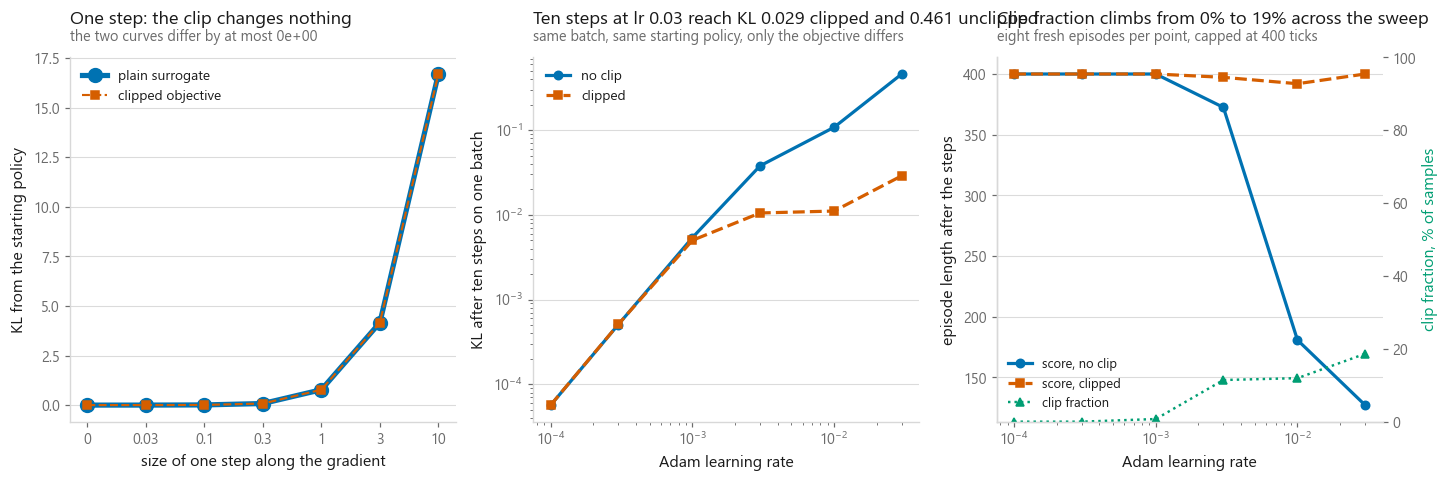

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.3))
x = np.arange(len(SIZES))

ax = axes[0]
ax.plot(x, single["KL, plain surrogate"], color=style.PALETTE[0], lw=3.4,
        marker=style.MARKERS[0], markersize=9, label="plain surrogate")
ax.plot(x, single["KL, clipped objective"], color=style.HIGHLIGHT, lw=1.4, ls="--",
        marker=style.MARKERS[1], markersize=5, label="clipped objective")
ax.set_xticks(x, [f"{s:g}" for s in SIZES])
ax.set_xlabel("size of one step along the gradient")
ax.set_ylabel("KL from the starting policy")
ax.legend(loc="upper left", fontsize=9)
style.title(ax, "One step: the clip changes nothing",
            f"the two curves differ by at most "
            f"{np.abs(single['KL, plain surrogate'] - single['KL, clipped objective']).max():.0e}")

ax = axes[1]
ax.plot(LRS, reuse["KL, no clip"], color=style.PALETTE[0], lw=2.1,
        marker=style.MARKERS[0], label="no clip")
ax.plot(LRS, reuse["KL, clipped"], color=style.HIGHLIGHT, lw=2.1, ls="--",
        marker=style.MARKERS[1], label="clipped")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Adam learning rate")
ax.set_ylabel("KL after ten steps on one batch")
ax.legend(loc="upper left", fontsize=9)
top = reuse.iloc[-1]
style.title(ax,
            f"Ten steps at lr {top['learning rate']:g} reach KL {top['KL, clipped']:.3g} "
            f"clipped and {top['KL, no clip']:.3g} unclipped",
            "same batch, same starting policy, only the objective differs")

ax = axes[2]
ax.plot(LRS, reuse["score, no clip"], color=style.PALETTE[0], lw=2.1,
        marker=style.MARKERS[0], label="score, no clip")
ax.plot(LRS, reuse["score, clipped"], color=style.HIGHLIGHT, lw=2.1, ls="--",
        marker=style.MARKERS[1], label="score, clipped")
ax.set_xscale("log")
ax.set_xlabel("Adam learning rate")
ax.set_ylabel("episode length after the steps")

# The clip fraction is a percentage, not a step count, so it gets its own axis
# rather than being drawn against a scale it does not belong on.
ax2 = ax.twinx()
ax2.plot(LRS, reuse["clip fraction"] * 100, color=style.PALETTE[2], lw=1.6, ls=":",
         marker=style.MARKERS[2], label="clip fraction")
ax2.set_ylabel("clip fraction, % of samples", color=style.PALETTE[2])
ax2.set_ylim(0, 100)
ax2.grid(False)
handles, labels = ax.get_legend_handles_labels()
extra_handles, extra_labels = ax2.get_legend_handles_labels()
ax.legend(handles + extra_handles, labels + extra_labels, loc="lower left", fontsize=8.5)

style.title(ax,
            f"Clip fraction climbs from {reuse['clip fraction'].min():.0%} to "
            f"{reuse['clip fraction'].max():.0%} across the sweep",
            "eight fresh episodes per point, capped at 400 ticks")

style.save(fig, FIG / "fig-05-clip-and-kl.png")

### Reading all of that together

The clip is a limit on how far **repeated optimisation of one batch** can carry
the policy, not a limit on the size of a single step. It works by switching off
the gradient from any sample whose probability has already moved far enough, so
the objective flattens out as the policy drifts from the one that collected the
data. The first step off the starting point is untouched, and the protection
arrives only afterwards.

Which gives a practical rule with a number attached. Print the clip fraction. If
it is near zero your ratios never leave the window, the clipped objective is the
plain surrogate, and whatever you attribute to PPO is coming from somewhere else.
If it is very high, most of your samples are contributing no gradient at all and
the extra epochs are burning compute for nothing. The middle of that range is
where PPO is actually working, and it is the one diagnostic that tells you which
regime you are in.

The other half of PPO is not in the objective at all. Reusing a batch several
times is what buys the sample efficiency, and reusing it is only defensible
because the ratio makes the correction. The clip is what stops the reuse from
eating the policy. Take the ratio away and the reuse is not even wrong, it is
meaningless, which is what the middle row of the training table is.

## Cheat sheet

| | |
|---|---|
| **Actor-critic** | The critic supplies the target as well as the baseline. Bootstrapping trades variance for bias, and the bias is the critic's error |
| **GAE λ** | 1 is Monte Carlo minus a baseline, 0 is one-step TD, and the usual choice sits just under 1. It is a bias-variance dial and nothing else |
| **Terminal versus cut off** | $V = 0$ only when the episode really ended. A time limit is not an ending, and treating it as one teaches the critic that success is followed by nothing |
| **PPO ratio** | $\pi_\theta / \pi_{\theta_\text{old}}$, equal to 1 before the update. It is what makes several passes over one batch legitimate |
| **PPO clip** | Bounds the damage from repeated passes. It does not bound a single step, because at the starting point it is the identity |
| **Main dials** | Learning rate, epochs per batch, clip width, λ, episodes per batch |
| **Watch out** | A clip fraction near zero means the clip never fired and you are running plain surrogate reuse |
| **Sanity check** | Log KL from the collecting policy every batch. It is three lines and it is the number that predicts a collapse |
| **Next** | [Part 12](../../12-putting-it-together/), where every method in the book is put on one scoreboard |

## What to remember

1. 11-07 already had a learned baseline. What actor-critic adds is that the critic
   supplies the target too, which is bootstrapping and which introduces bias.
2. GAE is one backward pass and one number. λ = 1 recovers the previous chapter's
   estimator exactly, so the two chapters sit on one dial.
3. A quieter gradient is not automatically a better run. Measure the noise and the
   outcome separately, because the ranking can differ.
4. An episode cut off by a time limit has not terminated. Bootstrap its tail.
5. The probability ratio is what makes more than one gradient step per batch mean
   anything at all.
6. The clipped objective has the same gradient as the plain one at the starting
   point. It cannot prevent one oversized step, and it was never able to.
7. What it prevents is a batch being optimised until the policy has left the
   region the data describes. That is the regime PPO runs in, and the clip
   fraction is how you tell whether it is happening.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [Part 12, putting it together](../../12-putting-it-together/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#PPO` `#ActorCritic` `#GAE` `#PolicyGradient` `#PyTorch`
`#DeepRL` `#MLTutorial` `#LearnMachineLearning` `#AI`